### Preamble

In [ ]:
%load_ext autoreload
%autoreload 2

# for storing .pkl table data, .tex and preview pdf
file_prefix = 'results/milp-benchmark-03-nov'

from traffic_scheduling.single.basics import generate_instance, uniform, bimodal_exponential
import pandas as pd
import numpy as np
import time 
from datetime import datetime, timedelta
from itertools import product

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Mixed-integer linear programming benchmark

We measure the average running time of the MILP solver for different selections of cutting planes. To keep the total benchmark time manageable, we set a time limit for each instance.

## Experiment specification

In [38]:
# static parameters
R = 4
# F = bimodal_exponential(p=0.1, s1=0.1, s2= 5.6) # low
# F = bimodal_exponential(p=0.5, s1=0.1, s2=10.00) # high
F = uniform()
number_of_instances = 10
timelimit = 60

cut_names = {
    2 : 'conjunctive',
    3 : 'disjunctive',
}

# variables
ns = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]
cuts_combinations = [[], [2], [3], [2,3]]

results = pd.DataFrame(product(ns, cuts_combinations), columns=['vehicles_per_route', 'cuts'])
# write full cut combination names
def cut_name(cuts):
    if not cuts: return 'vanilla'
    return ', '.join([cut_names[x] for x in cuts])
results['cuts_str'] = results['cuts'].apply(cut_name)

# generate instance sets, one for each size
instance_sets = { n: [generate_instance(F, n, R) for _ in range(number_of_instances)] for n in ns }

Try to find a rough bound on the total time required for this experiment.

In [39]:
time_bound = timedelta(seconds=len(ns) * len(cuts_combinations) * number_of_instances * timelimit)
print(f"runtime upper bound: {time_bound}")

runtime upper bound: 6:40:00


## Measure running times

Run the benchmark, this may take a while...

In [40]:
started = datetime.now()
print(f"started: {started.strftime('%H:%M:%S')}")
end = started + time_bound
print(f"done before: {end.strftime('%H:%M:%S')}")

for i, row in results.iterrows():
    instances = instance_sets[row['vehicles_per_route']]
    times = []
    for instance in instances:
        start = time.time()
        instance.solve(cutting_planes=row['cuts'], timelimit=timelimit)
        times.append(time.time() - start)
    results.loc[i, 'time'] = np.array(times).mean()
    results.loc[i, 'std'] = np.array(times).std()

    # checkpoint
    results.to_pickle(f'{file_prefix}.pkl')

started: 02:15:10
done before: 08:55:10


## Reporting

### Table wrangling

Pivot the data and group by cuts.

In [41]:
pivoted = results.pivot(index='vehicles_per_route', columns='cuts_str',  values=['time', 'std'])
pivoted = pivoted.swaplevel(axis=1).sort_index(axis=1)
pivoted

cuts_str           conjunctive            conjunctive, disjunctive             \
                           std       time                      std       time   
vehicles_per_route                                                              
2                     0.010339   0.041853                 0.010153   0.030850   
4                     0.013222   0.161818                 0.028773   0.167509   
6                     0.068904   0.531079                 0.077212   0.512870   
8                     0.230847   1.848575                 0.338959   1.614378   
10                    1.988121  11.940416                 1.056621   4.985397   
12                    1.955568  25.256415                 8.193349  18.279653   
14                    4.967912  45.856437                12.984697  42.635512   
16                    0.010272  60.057258                 5.385152  58.287150   
18                    0.006725  60.062942                 0.011149  60.079918   
20                    0.011973  60.075596                 0.012791  60.093043   

cuts_str           disjunctive              vanilla             
                           std       time       std       time  
vehicles_per_route                                              
2                     0.011395   0.054027  0.027247   0.094117  
4                     0.051562   0.327928  7.044668  46.755711  
6                     0.531785   2.802518  0.027872  60.158731  
8                     2.270914  19.522345  0.027448  60.107056  
10                    0.008655  60.052429  0.038332  60.084554  
12                    0.002677  60.057262  0.028856  60.048531  
14                    0.018518  60.076329  0.007199  60.052585  
16                    0.037519  60.098147  0.027790  60.065613  
18                    0.030527  60.096785  0.004088  60.062800  
20                    0.022478  60.096543  0.024184  60.077846

Renaming and number formatting. Highlight the lowest running time in each row.

In [ ]:
from traffic_scheduling.single.util import format_duration

table = pivoted.copy()

# convert to gaps strings
# 2-leveled columns, so apply formatting at every columns,
# e.g. (PPO1, gap), (PPO2, gap), separately
time_cols = table.columns[table.columns.isin(['time'], 1)]
table = table.astype({ col: str for col in time_cols })

def bold_min_sublevel(row):
    new_row = row.copy()
    cols_x = row.index.get_level_values(1) == 'time'
    # find min among these columns
    min_val = row[cols_x].astype(float).min()
    # apply bold only to min in that sublevel
    new_row[cols_x] = [
        f"\\textbf{{{format_duration(float(v))}}}" if float(v)==min_val \
            else f"{format_duration(float(v))}" for v in row[cols_x]]
    return new_row

# hightlight min gap, in each row
table = table.apply(bold_min_sublevel, axis=1)

# further renaming to taste
table.columns.names = ["cuts", "measurement"]
table.index.rename(r'n', inplace=True)

table

cuts        conjunctive                conjunctive, disjunctive  \
measurement         std           time                      std   
n                                                                 
2              0.010339           (0s)                 0.010153   
4              0.013222  \textbf{(0s)}                 0.028773   
6              0.068904           (1s)                 0.077212   
8              0.230847           (2s)                 0.338959   
10             1.988121          (12s)                 1.056621   
12             1.955568          (25s)                 8.193349   
14             4.967912          (46s)                12.984697   
16             0.010272           (1m)                 5.385152   
18             0.006725           (1m)                 0.011149   
20             0.011973  \textbf{(1m)}                 0.012791   

cuts                        disjunctive          vanilla                 
measurement            time         std   time       std           time  
n                                                                        
2             \textbf{(0s)}    0.011395   (0s)  0.027247           (0s)  
4                      (0s)    0.051562   (0s)  7.044668          (47s)  
6             \textbf{(1s)}    0.531785   (3s)  0.027872           (1m)  
8             \textbf{(2s)}    2.270914  (20s)  0.027448           (1m)  
10            \textbf{(5s)}    0.008655   (1m)  0.038332           (1m)  
12           \textbf{(18s)}    0.002677   (1m)  0.028856           (1m)  
14           \textbf{(43s)}    0.018518   (1m)  0.007199           (1m)  
16           \textbf{(58s)}    0.037519   (1m)  0.027790           (1m)  
18                     (1m)    0.030527   (1m)  0.004088  \textbf{(1m)}  
20                     (1m)    0.022478   (1m)  0.024184           (1m)

### LaTeX table export

Export the table to LaTeX, for inclusion in report.

In [43]:
# latex \begin{table}{...} format
column_format = 'c|cc|cc|cc|cc'
latex_table = table.to_latex(multirow=True, column_format=column_format, multicolumn_format='c',
                               escape=False, float_format="%.2f",
                               caption="Performance Table")
print(latex_table)

\begin{table}
\caption{Performance Table}
\begin{tabular}{c|cc|cc|cc|cc}
\toprule
cuts & \multicolumn{2}{c}{conjunctive} & \multicolumn{2}{c}{conjunctive, disjunctive} & \multicolumn{2}{c}{disjunctive} & \multicolumn{2}{c}{vanilla} \\
measurement & std & time & std & time & std & time & std & time \\
n &  &  &  &  &  &  &  &  \\
\midrule
2 & 0.01 & (0s) & 0.01 & \textbf{(0s)} & 0.01 & (0s) & 0.03 & (0s) \\
4 & 0.01 & \textbf{(0s)} & 0.03 & (0s) & 0.05 & (0s) & 7.04 & (47s) \\
6 & 0.07 & (1s) & 0.08 & \textbf{(1s)} & 0.53 & (3s) & 0.03 & (1m) \\
8 & 0.23 & (2s) & 0.34 & \textbf{(2s)} & 2.27 & (20s) & 0.03 & (1m) \\
10 & 1.99 & (12s) & 1.06 & \textbf{(5s)} & 0.01 & (1m) & 0.04 & (1m) \\
12 & 1.96 & (25s) & 8.19 & \textbf{(18s)} & 0.00 & (1m) & 0.03 & (1m) \\
14 & 4.97 & (46s) & 12.98 & \textbf{(43s)} & 0.02 & (1m) & 0.01 & (1m) \\
16 & 0.01 & (1m) & 5.39 & \textbf{(58s)} & 0.04 & (1m) & 0.03 & (1m) \\
18 & 0.01 & (1m) & 0.01 & (1m) & 0.03 & (1m) & 0.00 & \textbf{(1m)} \\
20 & 0.01 & \tex

In [44]:
import re

# some further automated formatting (just search/replace)
# 1. remove all \cline
latex_table = re.sub(r'\\cline\{.*?\}\s*\n?', '', latex_table)
# 2. remove \toprule
latex_table = re.sub(r'\\toprule\s*\n?', '', latex_table)
# 3. replace \bottomrule with \midrule
latex_table = re.sub(r'\\bottomrule\s*\n?', '\\\\midrule\n', latex_table)
# 4. TODO: extract tabular
# latex_table = re.sub()
match = re.search(r"\\begin\{tabular.*?\\end\{tabular\}", latex_table, re.DOTALL)
latex_table = match.group(0)

# write complete latex template for preview
# (with timestamp)
from datetime import datetime
now = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
date_line = f"\\noindent\\textit{{Compiled on: {now}}}\\\\\n"
latex = f"""
\\documentclass{{article}}
\\usepackage{{booktabs}}
\\usepackage{{multirow}}
\\usepackage{{siunitx}}
\\usepackage[skip=10pt]{{caption}}
\\usepackage[margin=1cm]{{geometry}}
\\begin{{document}}
\\begin{{table}}
{latex_table}
\\end{{table}}
{date_line}
\\end{{document}}"""

with open(file_prefix + '.preview.tex', 'w') as f:
    f.write(latex)
!tectonic {file_prefix + '.preview.tex'}

Running TeX ...
Rerunning TeX because "milp-benchmark-03-nov.preview.aux" changed ...
Running xdvipdfmx ...
Writing `results/milp-benchmark-03-nov.preview.pdf` (11.79 KiB)
Skipped writing 1 intermediate files (use --keep-intermediates to keep them)


In [45]:
# write only table, for direct use in report
with open(file_prefix + '.tex', 'w') as f:
    f.write(latex_table)

### Plot

These could help understand the scale of the results and the variance across instances.

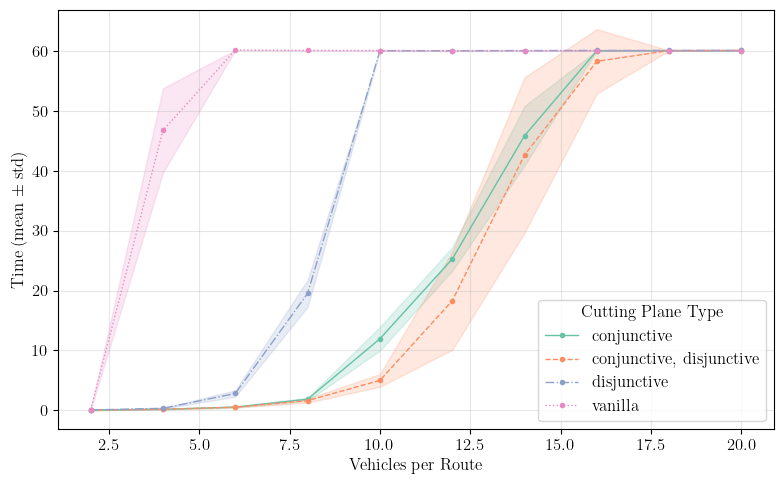

In [ ]:
from traffic_scheduling.single.util import get_figsize, set_plot_defaults
set_plot_defaults()
import matplotlib.pyplot as plt
# import seaborn as sns

# sns.set_style("whitegrid")
# sns.set_context("paper")  # or "talk" for presentations

fig, ax = plt.subplots(figsize=(8,5))
line_styles = ['-', '--', '-.', ':']

df = pivoted
categories = df.columns.get_level_values(0).unique()

from matplotlib.colors import ListedColormap
# colors = ['black', 'blue', 'red', 'indigo']
colors = plt.cm.Set2(range(len(categories)))

for category, style, color in zip(categories, line_styles, colors):
    mean = df[category]['time']
    std = df[category]['std']

    ax.plot(df.index, mean, linestyle=style, marker='o', 
            linewidth=1, markersize=3,
            color=color, label=category)

    # shaded region for std: clip lower bound at 0
    lower_bound = mean - std
    upper_bound = mean + std

    ax.fill_between(df.index, lower_bound, upper_bound, alpha=0.2, color=color)

ax.set_xlabel(r'Vehicles per Route')
ax.set_ylabel(r'Time (mean $\pm$ std)')
ax.legend(title=r'Cutting Plane Type')

# sns.despine()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('./figures/milp-benchmark-styling.pdf');
plt.show();